Fitted parameters:
  B (Slope) = 0.0032 ± 0.0001
  C (Intercept) = -0.0721 ± 0.0230


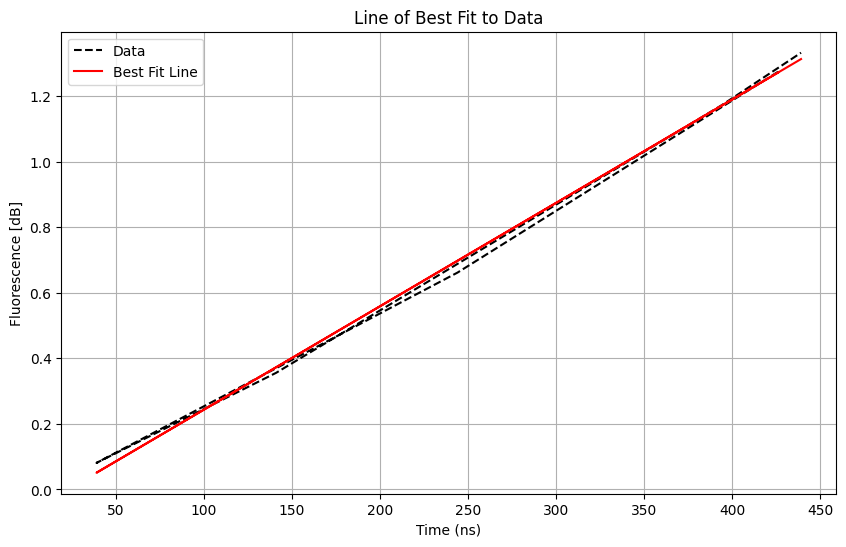

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import csv
import pandas as pd
from scipy.stats import chi2
from scipy.stats import norm
from google.colab import files

# Define the linear function for line of best fit
def linear_fit(x, B, C):
    return B * x + C

# Your time and signal data arrays
time = np.array([
    426, 244, 39, 141, 394, 439
])

signal = np.array([
    1.275, 0.662, 0.081, 0.356, 1.173, 1.333
])

# Initial guess for linear fit: [Slope, Intercept]
initial_guess = [-0.002, -2.0]  # Adjust these values based on your data trend

try:
    # Fit the linear function to the data
    popt, pcov = curve_fit(linear_fit, time, signal, p0=initial_guess)

    # Extract fitted parameters
    B_fit, C_fit = popt
    B_error, C_error = np.sqrt(np.diag(pcov))

    # Print the fitted parameters with their errors
    print(f"Fitted parameters:")
    print(f"  B (Slope) = {B_fit:.4f} ± {B_error:.4f}")
    print(f"  C (Intercept) = {C_fit:.4f} ± {C_error:.4f}")

    # Plotting the results
    plt.figure(figsize=(10, 6))
    plt.plot(time, signal, 'k--', label='Data')
    plt.plot(time, linear_fit(time, *popt), 'r-', label='Best Fit Line')
    plt.xlabel('Time (ns)')
    plt.ylabel('Fluorescence [dB]')
    plt.title('Line of Best Fit to Data')
    plt.legend()
    plt.grid(True)
    plt.savefig("Best_Fit_Line.png")
    plt.show()

except Exception as e:
    print("An error occurred during curve fitting:", e)